/var/folders/5w/511b227d2z53cxgmdw8rgp400000gp/T/ipykernel_58644/3004870413.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  llm_output_numnot1_gpt['all_scores'] = llm_output_numnot1_gpt['all_scores'].apply(lambda x: eval(x))
/var/folders/5w/511b227d2z53cxgmdw8rgp400000gp/T/ipykernel_58644/3004870413.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  llm_output_numnot1_gpt['output_scores'] = llm_output_numnot1_gpt['output_scores'].apply(lambda x: eval(x))
/var/folders/5w/511b227d2z53cxgmdw8rgp400000gp

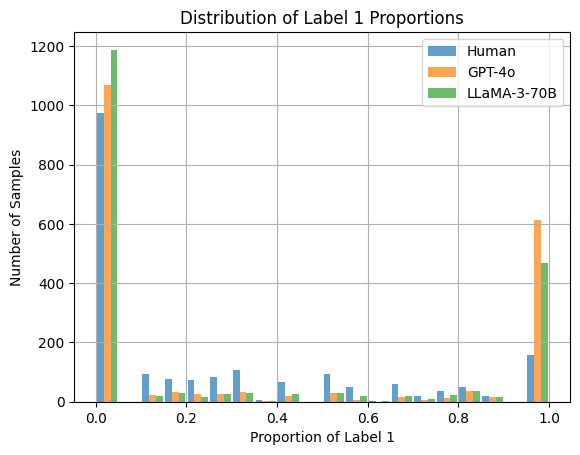

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load output from GPT-4o and LLaMA-3-70B
llm_output_gpt = pd.read_csv('./gpt-4o_temperature1_ori-en-CandR.csv')
llm_output_llama = pd.read_csv('./llama3-70b_temperature1_ori-en-CandR.csv')

# get the number of annotators for each sample
llm_output_gpt['num_annotator'] = llm_output_gpt['output_scores'].apply(lambda x: len(eval(x)))
llm_output_llama['num_annotator'] = llm_output_llama['output_scores'].apply(lambda x: len(eval(x)))

# filter out samples with only one annotator
llm_output_numnot1_gpt = llm_output_gpt[llm_output_gpt['num_annotator'] > 1]
llm_output_numnot1_llama = llm_output_llama[llm_output_llama['num_annotator'] > 1]

# Convert values of the annotations column and output_scores column from strings to lists and calculate the percentage of 1 in the lists
llm_output_numnot1_gpt['annotations'] = llm_output_numnot1_gpt['annotations'].apply(lambda x: eval(x))
llm_output_numnot1_gpt['output_scores'] = llm_output_numnot1_gpt['output_scores'].apply(lambda x: eval(x))
llm_output_numnot1_gpt['percentage_1_human'] = llm_output_numnot1_gpt['annotations'].apply(lambda x: x.count(1)/len(x))
llm_output_numnot1_gpt['percentage_1_gpt'] = llm_output_numnot1_gpt['output_scores'].apply(lambda x: x.count(1)/len(x))
llm_output_numnot1_llama['percentage_1_llama'] = llm_output_numnot1_llama['output_scores'].apply(lambda x: eval(x)).apply(lambda x: x.count(1)/len(x))

# plot the distribution of the percentage of 1 in the lists for human, GPT-4o and LLaMA-3-70B
data1 = llm_output_numnot1_gpt['percentage_1_human']
data2 = llm_output_numnot1_gpt['percentage_1_gpt']
data3 = llm_output_numnot1_llama['percentage_1_llama']

bins = np.linspace(0, 1, 21)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = bins[1] - bins[0]

counts1, _ = np.histogram(data1, bins=bins)
counts2, _ = np.histogram(data2, bins=bins)
counts3, _ = np.histogram(data3, bins=bins)

bar_width = bin_width * 0.3 
offset = bar_width    

plt.bar(bin_centers - offset, counts1, width=bar_width, alpha=0.7, label='Human', align='center')
plt.bar(bin_centers         , counts3, width=bar_width, alpha=0.7, label='GPT-4o', align='center')
plt.bar(bin_centers + offset, counts2, width=bar_width, alpha=0.7, label='LLaMA-3-70B', align='center')

plt.xlabel('Proportion of Label 1')
plt.ylabel('Number of Samples')
plt.title('Distribution of Label 1 Proportions')
plt.legend()
plt.grid(True)
plt.savefig("./label 1 number distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()